<a href="https://colab.research.google.com/github/emilsar/Cedars/blob/main/project3/Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Cedars Data

In [1]:
!git clone https://github.com/emilsar/Cedars.git
%cd Cedars/Project3
! python 1_prepdata.py
from skimage.io import imread
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from skimage.color import rgb2gray
from skimage.filters import sobel, scharr, apply_hysteresis_threshold, gaussian
from skimage.feature import canny
from skimage.measure import regionprops,regionprops_table
from skimage.morphology import binary_opening, disk, binary_closing, binary_dilation, binary_erosion
from skimage.draw import rectangle_perimeter
from scipy.ndimage import label as scilabel
import cv2
import matplotlib; matplotlib.rcParams['figure.dpi']=300
urothelial_cells=pd.read_pickle("urothelial_cell_toy_data.pkl")
images=np.transpose(urothelial_cells["X"].numpy()*255,(0,2,3,1)).astype(np.uint8)
labels=urothelial_cells["y"]

Cloning into 'Cedars'...
remote: Enumerating objects: 1285, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 1285 (delta 18), reused 4 (delta 4), pack-reused 1257 (from 3)
Receiving objects: 100% (1285/1285), 1.23 GiB | 21.28 MiB/s, done.
Resolving deltas: 100% (498/498), done.
Updating files: 100% (896/896), done.
/content/Cedars/Project3


# Stage 1:  Grayscale, and Basic Segmentation

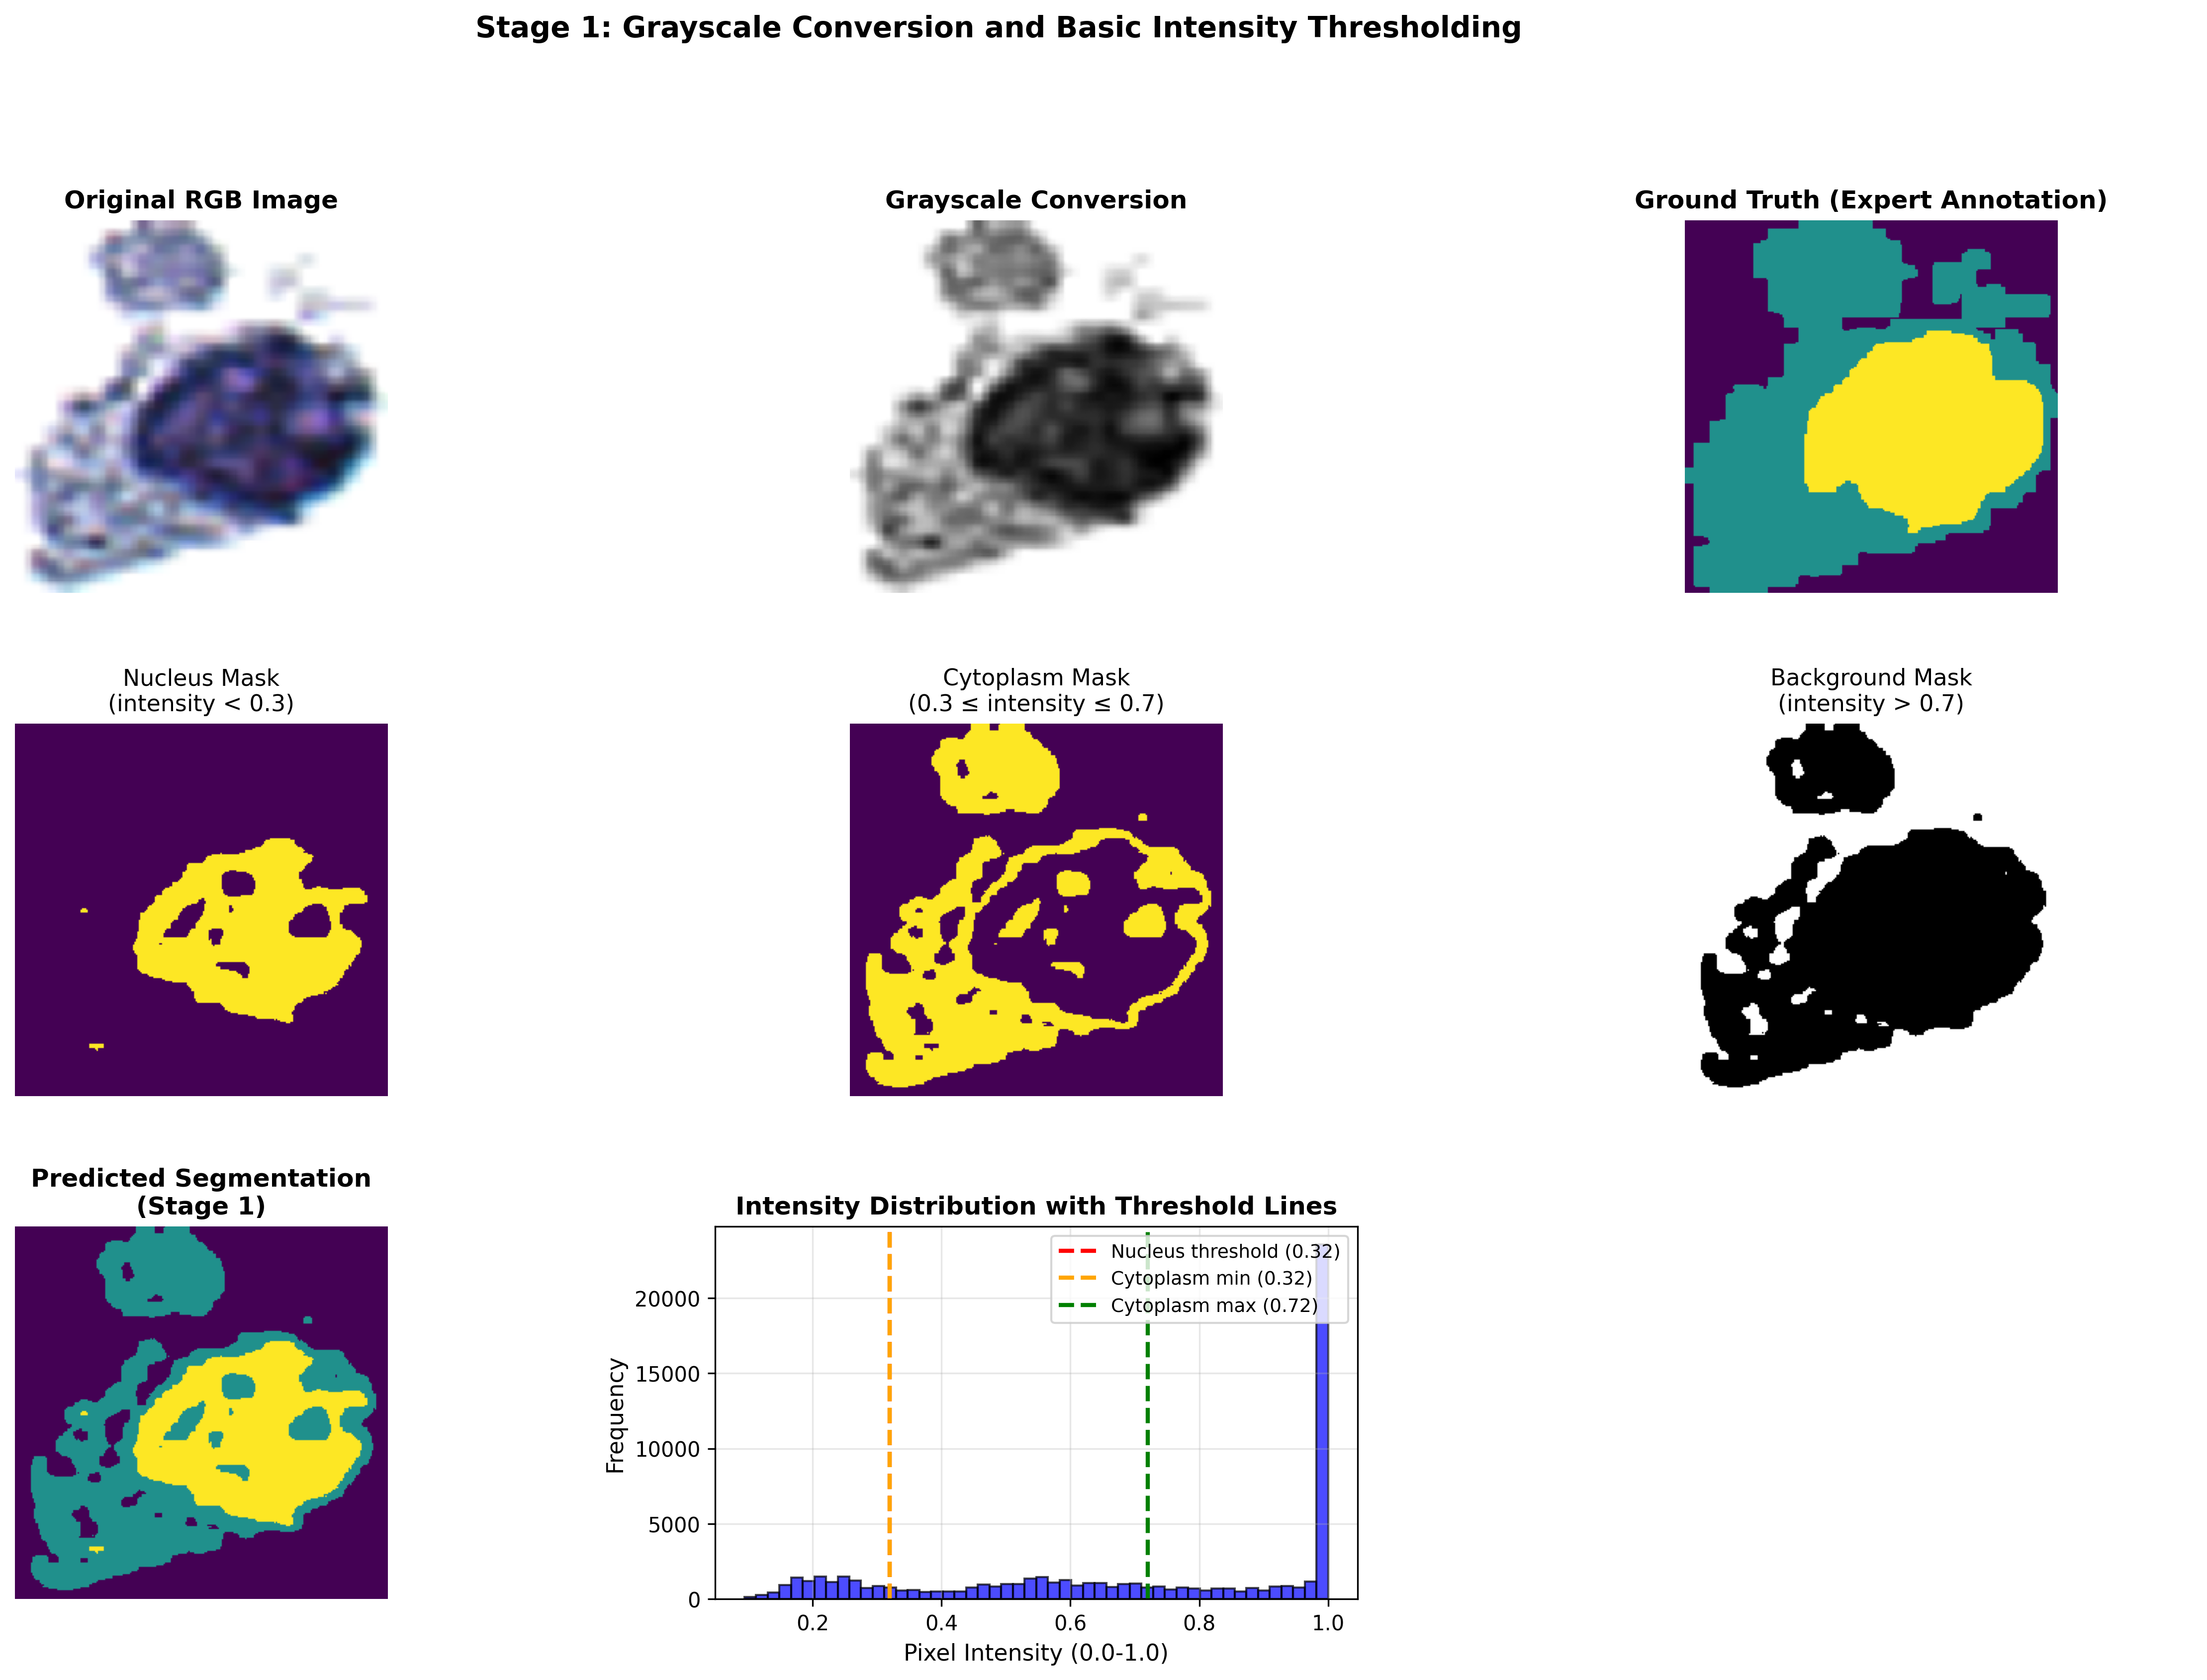


STAGE 1: GRAYSCALE CONVERSION AND BASIC SEGMENTATION
Class           Dice            IoU            
Background      0.7823          0.6424         
Cytoplasm       0.6564          0.4885         
Nucleus         0.8444          0.7308         
----------------------------------------------------------------------
Mean            0.7610          0.6206         

Image Number: 2
Nucleus Threshold: < 0.32
Cytoplasm Threshold: 0.32 to 0.72


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import gaussian_filter

# ============================================================================
# STAGE 1: GRAYSCALE CONVERSION AND BASIC INTENSITY THRESHOLDING
# ============================================================================

# PARAMETERS (User-adjustable)
image_number = 2
nucleus_max = 0.32      # Intensity threshold for nucleus (dark pixels)
cytoplasm_min = 0.32    # Lower bound for cytoplasm (mid-gray)
cytoplasm_max = 0.72    # Upper bound for cytoplasm

# Get the image
img = images[image_number]
labels_true = labels[image_number]

# STEP 1: Grayscale Conversion
# Using BT.709 standard (modern HDTV): 0.2125*R + 0.7154*G + 0.0721*B
img_uint8 = img.astype(np.uint8)
img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

# STEP 2: Intensity-Based Segmentation
nucleus_mask = (img_gray < nucleus_max).astype(int)
cytoplasm_mask = np.logical_and(
    img_gray >= cytoplasm_min,
    img_gray <= cytoplasm_max
).astype(int)
background_mask = (img_gray > cytoplasm_max).astype(int)

# STEP 3: Combine into 3-class segmentation
segmented = np.zeros_like(img_gray, dtype=int)
segmented[nucleus_mask == 1] = 2
segmented[cytoplasm_mask == 1] = 1
segmented[background_mask == 1] = 0

# STEP 4: Calculate Metrics
metrics_stage1 = calculate_all_metrics(segmented, labels_true, class_labels=[0, 1, 2])

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
fig.subplots_adjust(hspace=0.35, wspace=0.3)

# Row 1: Input and Ground Truth
axes[0, 0].imshow(img)
axes[0, 0].set_title("Original RGB Image", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_gray, cmap='gray')
axes[0, 1].set_title("Grayscale Conversion", fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(labels_true, cmap='viridis', vmin=0, vmax=2)
axes[0, 2].set_title("Ground Truth (Expert Annotation)", fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Segmentation Masks
axes[1, 0].imshow(nucleus_mask, cmap='viridis', vmin=0, vmax=1)
axes[1, 0].set_title("Nucleus Mask\n(intensity < 0.3)", fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(cytoplasm_mask, cmap='viridis', vmin=0, vmax=1)
axes[1, 1].set_title("Cytoplasm Mask\n(0.3 ≤ intensity ≤ 0.7)", fontsize=11)
axes[1, 1].axis('off')

axes[1, 2].imshow(background_mask, cmap='gray')
axes[1, 2].set_title("Background Mask\n(intensity > 0.7)", fontsize=11)
axes[1, 2].axis('off')

# Row 3: Segmentation and Histogram
axes[2, 0].imshow(segmented, cmap='viridis', vmin=0, vmax=2)
axes[2, 0].set_title("Predicted Segmentation\n(Stage 1)", fontsize=12, fontweight='bold')
axes[2, 0].axis('off')

# Intensity Histogram with thresholds
axes[2, 1].hist(img_gray.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[2, 1].axvline(nucleus_max, color='red', linestyle='--', linewidth=2, label=f'Nucleus threshold ({nucleus_max})')
axes[2, 1].axvline(cytoplasm_min, color='orange', linestyle='--', linewidth=2, label=f'Cytoplasm min ({cytoplasm_min})')
axes[2, 1].axvline(cytoplasm_max, color='green', linestyle='--', linewidth=2, label=f'Cytoplasm max ({cytoplasm_max})')
axes[2, 1].set_xlabel('Pixel Intensity (0.0-1.0)', fontsize=11)
axes[2, 1].set_ylabel('Frequency', fontsize=11)
axes[2, 1].set_title("Intensity Distribution with Threshold Lines", fontsize=12, fontweight='bold')
axes[2, 1].legend(fontsize=9)
axes[2, 1].grid(alpha=0.3)

axes[2, 2].axis('off')

plt.suptitle('Stage 1: Grayscale Conversion and Basic Intensity Thresholding',
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

# Print metrics
print("\n" + "="*70)
print("STAGE 1: GRAYSCALE CONVERSION AND BASIC SEGMENTATION")
print("="*70)
print_metrics(metrics_stage1)

print(f"\nImage Number: {image_number}")
print(f"Nucleus Threshold: < {nucleus_max}")
print(f"Cytoplasm Threshold: {cytoplasm_min} to {cytoplasm_max}")

# Stage 2: Adding Non-Local Means Denoising

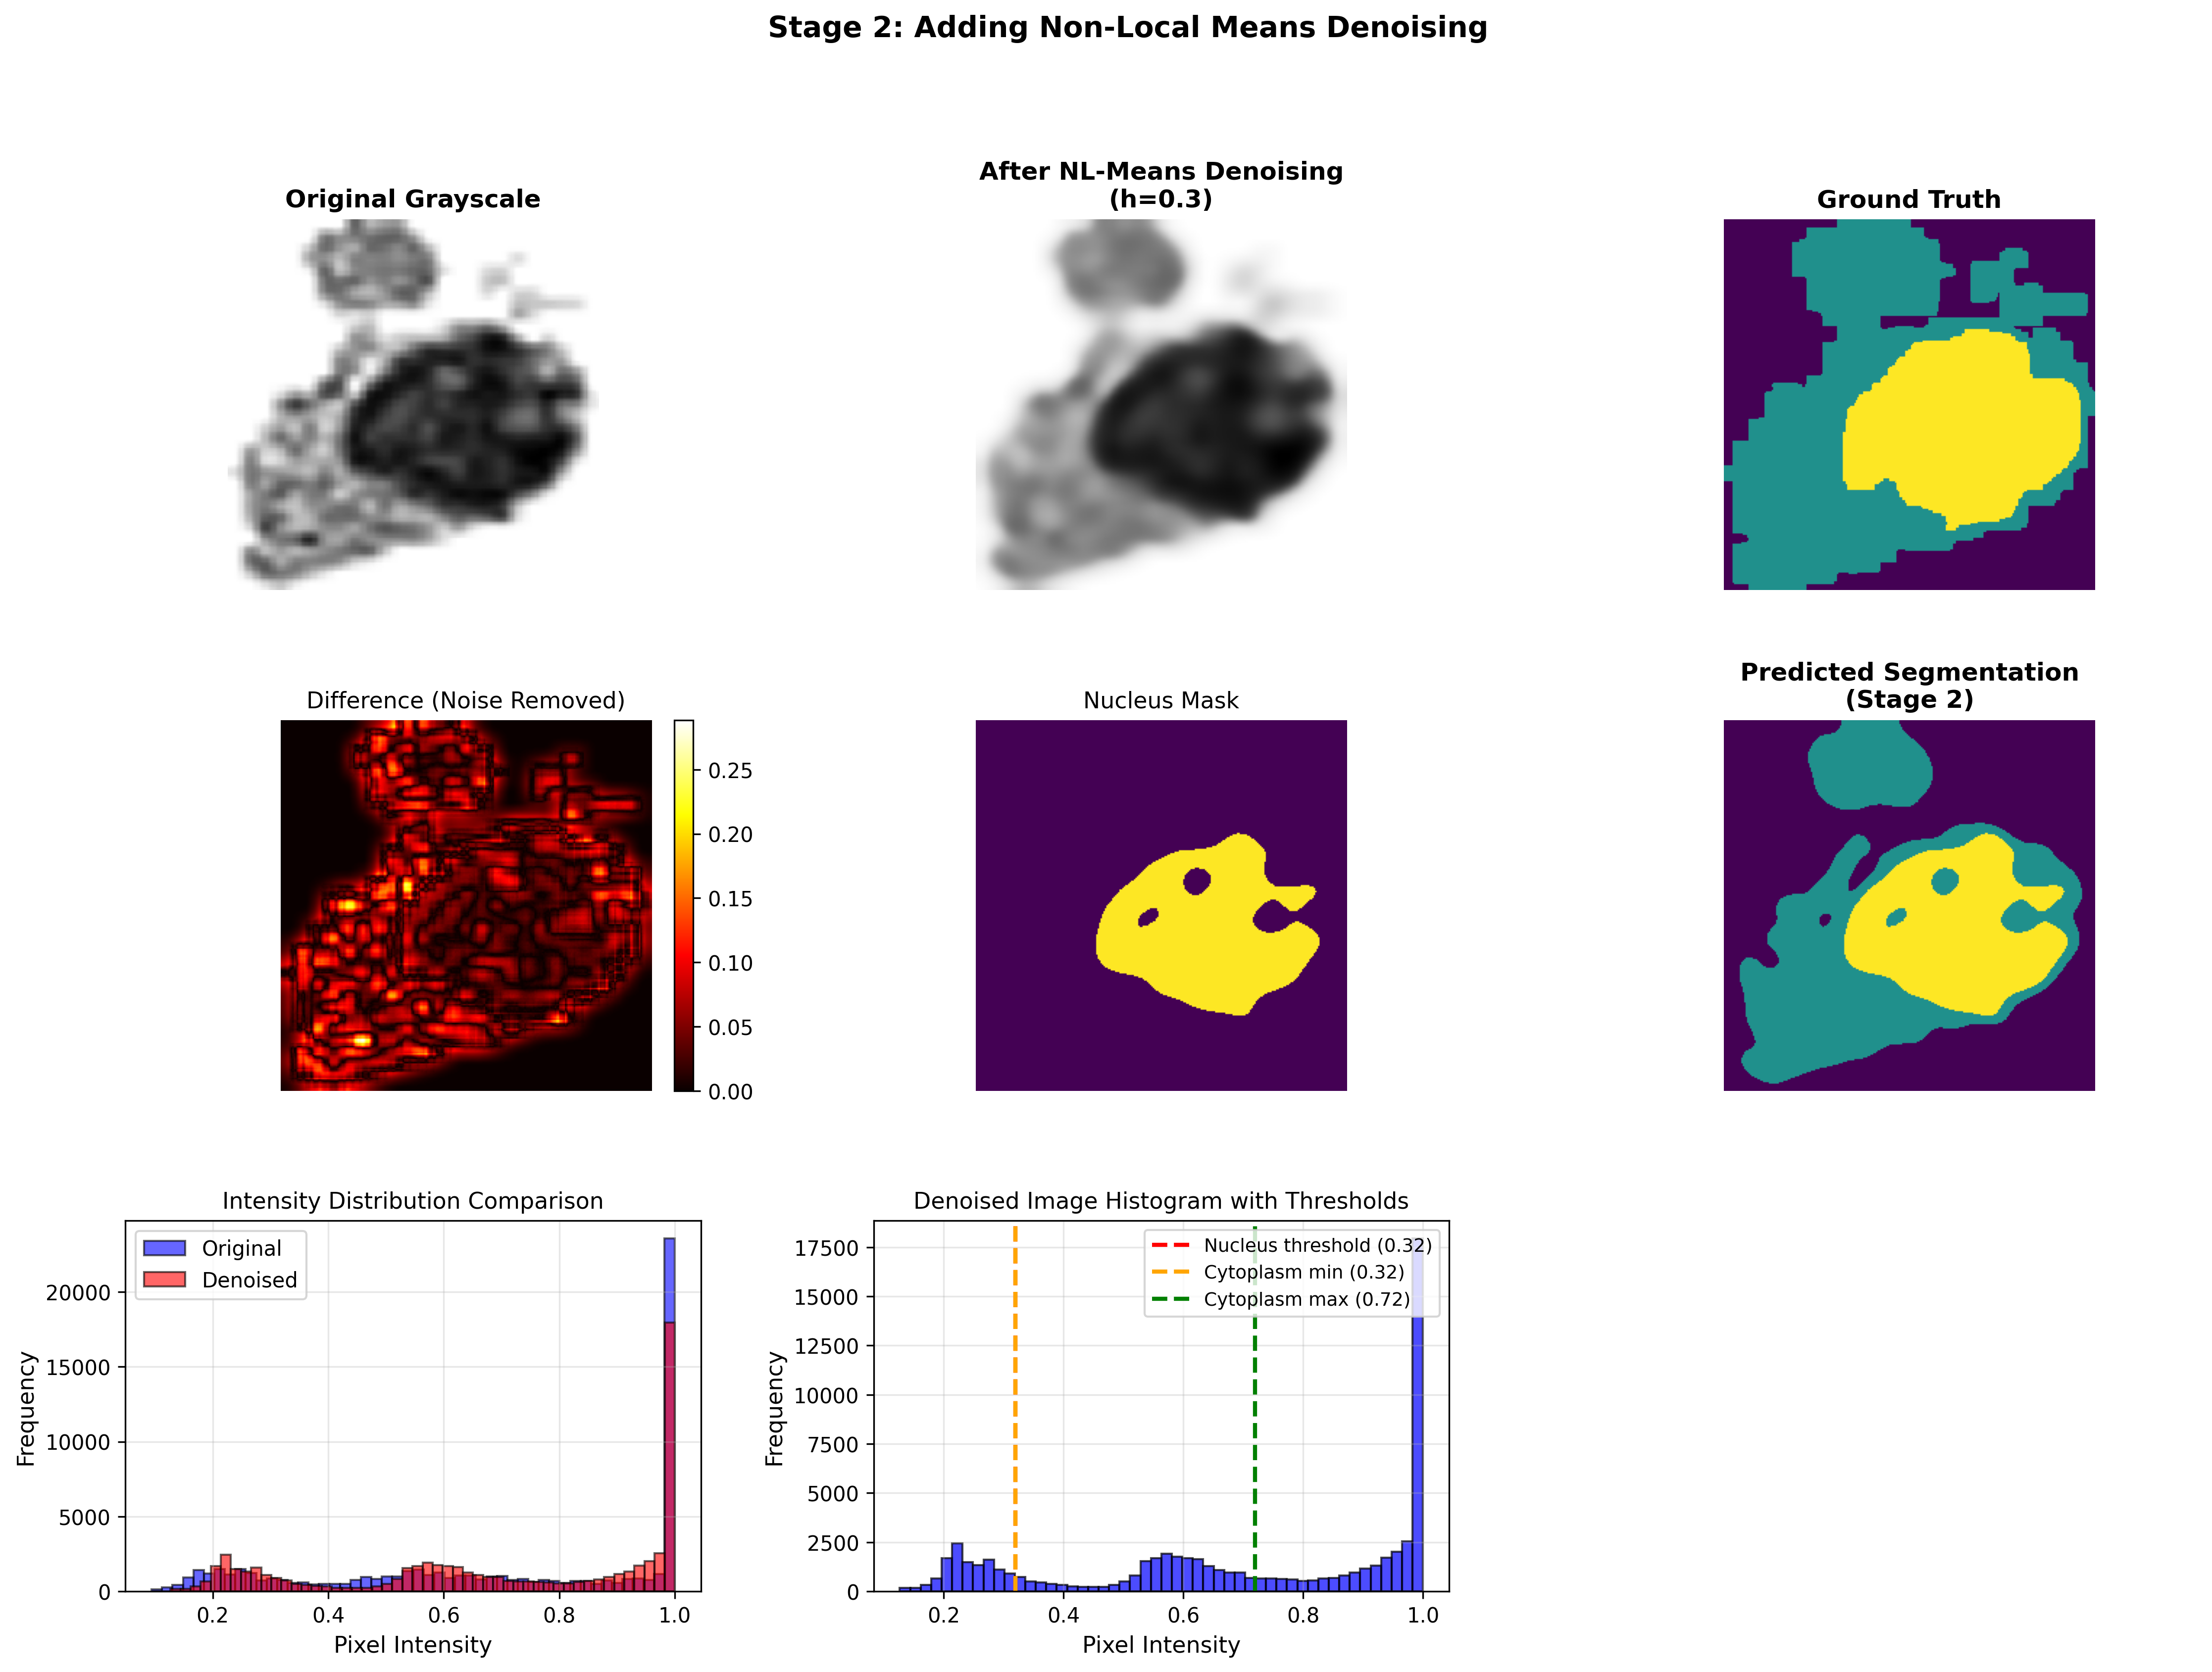


STAGE 2: NON-LOCAL MEANS DENOISING
Class           Dice            IoU            
Background      0.7936          0.6578         
Cytoplasm       0.6846          0.5204         
Nucleus         0.8596          0.7537         
----------------------------------------------------------------------
Mean            0.7793          0.6440         

STAGE COMPARISON: Stage 1 → Stage 2
Metric               Stage 1         Stage 2         Improvement    
----------------------------------------------------------------------
Dice_Mean            0.7610          0.7793          +0.0182
IoU_Mean             0.6206          0.6440          +0.0234


In [27]:
from skimage.restoration import denoise_nl_means

# ============================================================================
# STAGE 2: ADD NON-LOCAL MEANS DENOISING
# ============================================================================

# Additional parameter for Stage 2
nl_means_strength = 0.3  # h parameter: higher = more aggressive denoising

# STEP 1: Grayscale Conversion (same as Stage 1)
img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

# STEP 2: Non-Local Means Denoising
img_denoised = denoise_nl_means(
    img_gray,
    h=nl_means_strength,           # Denoising strength
    fast_mode=True,                # Use faster approximation
    patch_size=10,                 # Size of patches to compare
    patch_distance=10              # Search radius for similar patches
)

# STEP 3: Intensity-Based Segmentation (same as Stage 1, but on denoised image)
nucleus_mask = (img_denoised < nucleus_max).astype(int)
cytoplasm_mask = np.logical_and(
    img_denoised >= cytoplasm_min,
    img_denoised <= cytoplasm_max
).astype(int)
background_mask = (img_denoised > cytoplasm_max).astype(int)

# STEP 4: Combine into 3-class segmentation
segmented = np.zeros_like(img_denoised, dtype=int)
segmented[nucleus_mask == 1] = 2
segmented[cytoplasm_mask == 1] = 1
segmented[background_mask == 1] = 0

# STEP 5: Calculate Metrics
metrics_stage2 = calculate_all_metrics(segmented, labels_true, class_labels=[0, 1, 2])

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.subplots_adjust(hspace=0.35, wspace=0.3)

# Row 1: Comparison of Original vs Denoised
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title("Original Grayscale", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_denoised, cmap='gray')
axes[0, 1].set_title(f"After NL-Means Denoising\n(h={nl_means_strength})", fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(labels_true, cmap='viridis', vmin=0, vmax=2)
axes[0, 2].set_title("Ground Truth", fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Difference and Segmentation Masks
diff = np.abs(img_gray - img_denoised)
im = axes[1, 0].imshow(diff, cmap='hot')
axes[1, 0].set_title("Difference (Noise Removed)", fontsize=11)
axes[1, 0].axis('off')
plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(nucleus_mask, cmap='viridis', vmin=0, vmax=1)
axes[1, 1].set_title("Nucleus Mask", fontsize=11)
axes[1, 1].axis('off')

axes[1, 2].imshow(segmented, cmap='viridis', vmin=0, vmax=2)
axes[1, 2].set_title("Predicted Segmentation\n(Stage 2)", fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

# Row 3: Histograms Comparison
axes[2, 0].hist(img_gray.flatten(), bins=50, alpha=0.6, color='blue',
         label='Original', edgecolor='black')
axes[2, 0].hist(img_denoised.flatten(), bins=50, alpha=0.6, color='red',
         label='Denoised', edgecolor='black')
axes[2, 0].set_xlabel('Pixel Intensity', fontsize=11)
axes[2, 0].set_ylabel('Frequency', fontsize=11)
axes[2, 0].set_title("Intensity Distribution Comparison", fontsize=11)
axes[2, 0].legend()
axes[2, 0].grid(alpha=0.3)

axes[2, 1].hist(img_denoised.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[2, 1].axvline(nucleus_max, color='red', linestyle='--', linewidth=2,
            label=f'Nucleus threshold ({nucleus_max})')
axes[2, 1].axvline(cytoplasm_min, color='orange', linestyle='--', linewidth=2,
            label=f'Cytoplasm min ({cytoplasm_min})')
axes[2, 1].axvline(cytoplasm_max, color='green', linestyle='--', linewidth=2,
            label=f'Cytoplasm max ({cytoplasm_max})')
axes[2, 1].set_xlabel('Pixel Intensity', fontsize=11)
axes[2, 1].set_ylabel('Frequency', fontsize=11)
axes[2, 1].set_title("Denoised Image Histogram with Thresholds", fontsize=11)
axes[2, 1].legend(fontsize=9)
axes[2, 1].grid(alpha=0.3)

axes[2, 2].axis('off')

plt.suptitle('Stage 2: Adding Non-Local Means Denoising',
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

# Print metrics and comparison
print("\n" + "="*70)
print("STAGE 2: NON-LOCAL MEANS DENOISING")
print("="*70)
print_metrics(metrics_stage2)

print("\n" + "="*70)
print("STAGE COMPARISON: Stage 1 → Stage 2")
print("="*70)
print(f"{'Metric':<20} {'Stage 1':<15} {'Stage 2':<15} {'Improvement':<15}")
print("-"*70)
for key in metrics_stage1.keys():
    if 'Mean' in key:
        s1 = metrics_stage1[key]
        s2 = metrics_stage2[key]
        improvement = s2 - s1
        print(f"{key:<20} {s1:<15.4f} {s2:<15.4f} {improvement:+.4f}")

# Stage 3 - Adding Edge Enhancement and Gaussian Blur

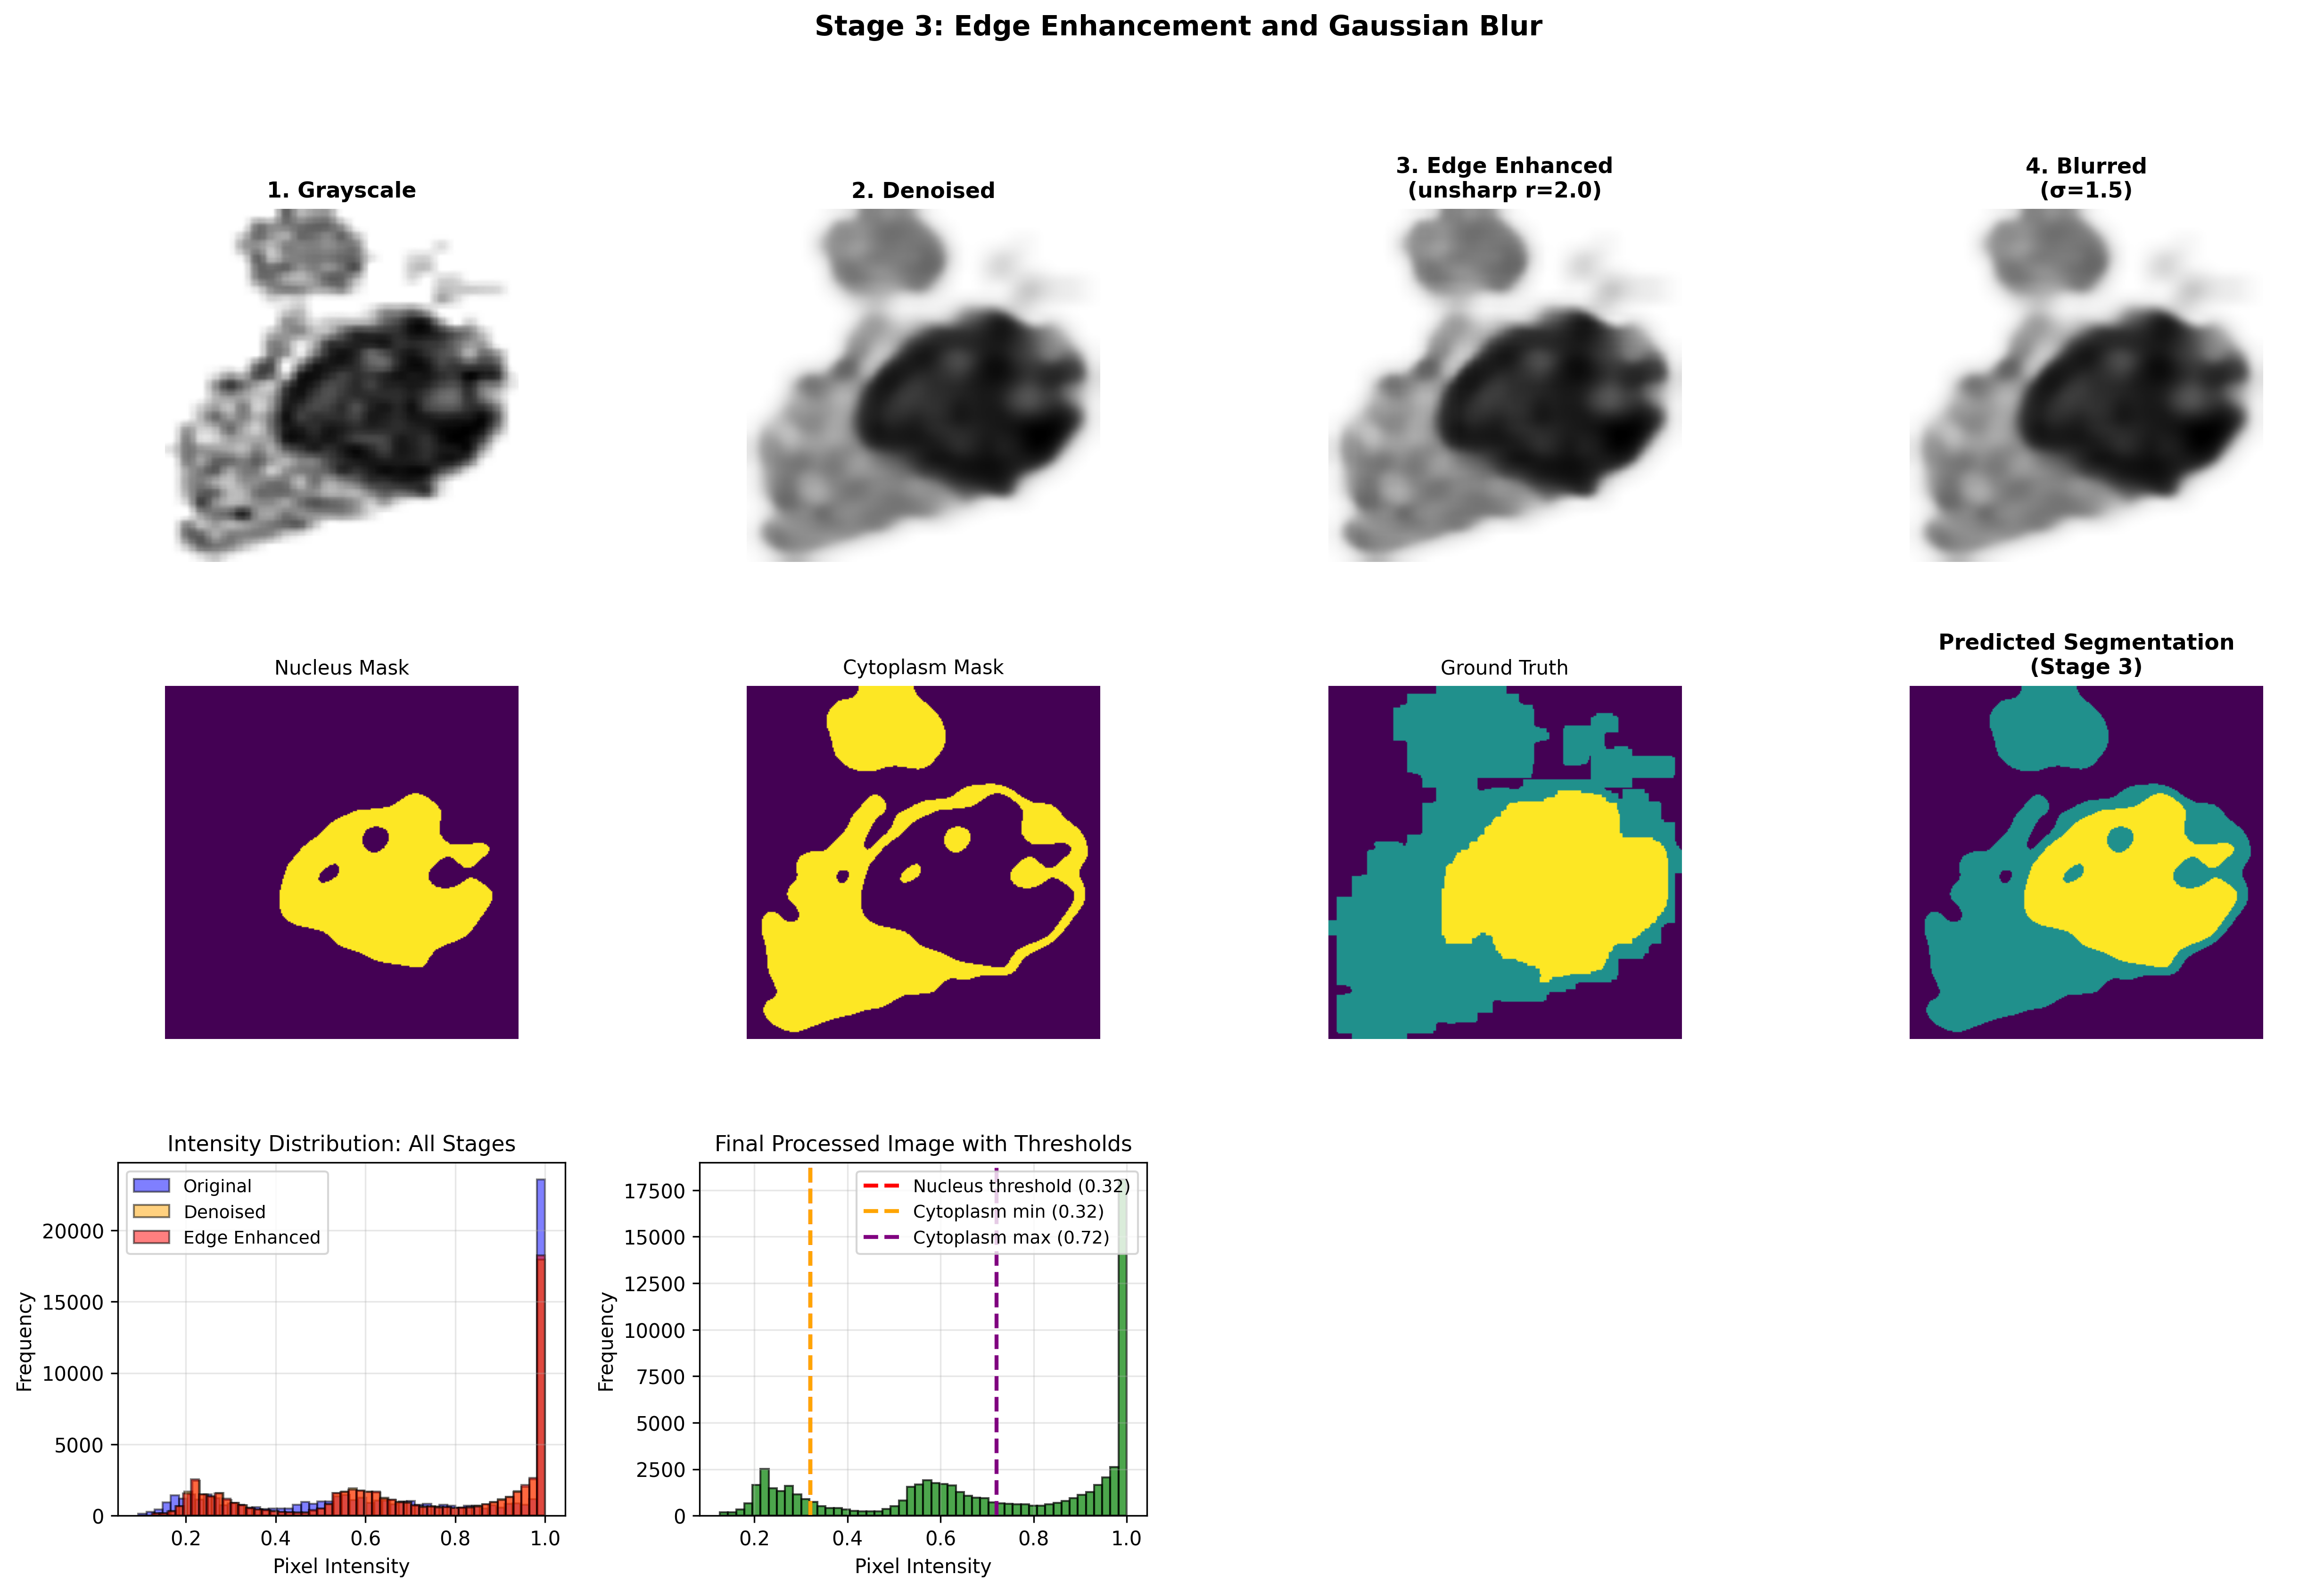


STAGE 3: EDGE ENHANCEMENT AND GAUSSIAN BLUR
Class           Dice            IoU            
Background      0.7935          0.6577         
Cytoplasm       0.6848          0.5207         
Nucleus         0.8607          0.7554         
----------------------------------------------------------------------
Mean            0.7797          0.6446         

CUMULATIVE STAGE COMPARISON: Stage 1 → Stage 2 → Stage 3
Metric                    Stage 1         Stage 2         Stage 3        
----------------------------------------------------------------------
Dice_Mean                 0.7610          0.7793          0.7797         
IoU_Mean                  0.6206          0.6440          0.6446         


In [28]:
from skimage.filters import unsharp_mask

# ============================================================================
# STAGE 3: ADD UNSHARP MASKING (EDGE ENHANCEMENT) AND GAUSSIAN BLUR
# ============================================================================

# Additional parameters for Stage 3
unsharp_radius = 2.0      # Radius of the blurred version in unsharp mask
unsharp_amount = 1.0      # How much detail to add back (1.0 = 100%)
blur_sigma = 1.5          # Gaussian blur standard deviation

# STEP 1: Grayscale Conversion (same as previous stages)
img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

# STEP 2: Non-Local Means Denoising (same as Stage 2)
img_denoised = denoise_nl_means(
    img_gray,
    h=nl_means_strength,
    fast_mode=True,
    patch_size=10,
    patch_distance=10
)

# STEP 3: Unsharp Masking (Edge Enhancement)
img_enhanced = unsharp_mask(
    img_denoised,
    radius=unsharp_radius,
    amount=unsharp_amount
)

# STEP 4: Gaussian Blur (Light smoothing)
img_blurred = gaussian_filter(img_enhanced, sigma=blur_sigma)

# STEP 5: Intensity-Based Segmentation (on the processed image)
nucleus_mask = (img_blurred < nucleus_max).astype(int)
cytoplasm_mask = np.logical_and(
    img_blurred >= cytoplasm_min,
    img_blurred <= cytoplasm_max
).astype(int)
background_mask = (img_blurred > cytoplasm_max).astype(int)

# STEP 6: Combine into 3-class segmentation
segmented = np.zeros_like(img_blurred, dtype=int)
segmented[nucleus_mask == 1] = 2
segmented[cytoplasm_mask == 1] = 1
segmented[background_mask == 1] = 0

# STEP 7: Calculate Metrics
metrics_stage3 = calculate_all_metrics(segmented, labels_true, class_labels=[0, 1, 2])

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.subplots_adjust(hspace=0.35, wspace=0.3)

# Row 1: Processing Pipeline
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title("1. Grayscale", fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_denoised, cmap='gray')
axes[0, 1].set_title("2. Denoised", fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_enhanced, cmap='gray')
axes[0, 2].set_title(f"3. Edge Enhanced\n(unsharp r={unsharp_radius})", fontsize=11, fontweight='bold')
axes[0, 2].axis('off')

axes[0, 3].imshow(img_blurred, cmap='gray')
axes[0, 3].set_title(f"4. Blurred\n(σ={blur_sigma})", fontsize=11, fontweight='bold')
axes[0, 3].axis('off')

# Row 2: Masks and Segmentation
axes[1, 0].imshow(nucleus_mask, cmap='viridis', vmin=0, vmax=1)
axes[1, 0].set_title("Nucleus Mask", fontsize=10)
axes[1, 0].axis('off')

axes[1, 1].imshow(cytoplasm_mask, cmap='viridis', vmin=0, vmax=1)
axes[1, 1].set_title("Cytoplasm Mask", fontsize=10)
axes[1, 1].axis('off')

axes[1, 2].imshow(labels_true, cmap='viridis', vmin=0, vmax=2)
axes[1, 2].set_title("Ground Truth", fontsize=10)
axes[1, 2].axis('off')

axes[1, 3].imshow(segmented, cmap='viridis', vmin=0, vmax=2)
axes[1, 3].set_title("Predicted Segmentation\n(Stage 3)", fontsize=11, fontweight='bold')
axes[1, 3].axis('off')

# Row 3: Histogram Progression
axes[2, 0].hist(img_gray.flatten(), bins=50, alpha=0.5, color='blue',
         label='Original', edgecolor='black')
axes[2, 0].hist(img_denoised.flatten(), bins=50, alpha=0.5, color='orange',
         label='Denoised', edgecolor='black')
axes[2, 0].hist(img_enhanced.flatten(), bins=50, alpha=0.5, color='red',
         label='Edge Enhanced', edgecolor='black')
axes[2, 0].set_xlabel('Pixel Intensity', fontsize=10)
axes[2, 0].set_ylabel('Frequency', fontsize=10)
axes[2, 0].set_title("Intensity Distribution: All Stages", fontsize=11)
axes[2, 0].legend(fontsize=9)
axes[2, 0].grid(alpha=0.3)

axes[2, 1].hist(img_blurred.flatten(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2, 1].axvline(nucleus_max, color='red', linestyle='--', linewidth=2,
             label=f'Nucleus threshold ({nucleus_max})')
axes[2, 1].axvline(cytoplasm_min, color='orange', linestyle='--', linewidth=2,
             label=f'Cytoplasm min ({cytoplasm_min})')
axes[2, 1].axvline(cytoplasm_max, color='purple', linestyle='--', linewidth=2,
             label=f'Cytoplasm max ({cytoplasm_max})')
axes[2, 1].set_xlabel('Pixel Intensity', fontsize=10)
axes[2, 1].set_ylabel('Frequency', fontsize=10)
axes[2, 1].set_title("Final Processed Image with Thresholds", fontsize=11)
axes[2, 1].legend(fontsize=9)
axes[2, 1].grid(alpha=0.3)

axes[2, 2].axis('off')
axes[2, 3].axis('off')

plt.suptitle('Stage 3: Edge Enhancement and Gaussian Blur',
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

# Print metrics and comparison
print("\n" + "="*70)
print("STAGE 3: EDGE ENHANCEMENT AND GAUSSIAN BLUR")
print("="*70)
print_metrics(metrics_stage3)

print("\n" + "="*70)
print("CUMULATIVE STAGE COMPARISON: Stage 1 → Stage 2 → Stage 3")
print("="*70)
print(f"{'Metric':<25} {'Stage 1':<15} {'Stage 2':<15} {'Stage 3':<15}")
print("-"*70)
for key in metrics_stage1.keys():
    if 'Mean' in key:
        s1 = metrics_stage1[key]
        s2 = metrics_stage2[key]
        s3 = metrics_stage3[key]
        print(f"{key:<25} {s1:<15.4f} {s2:<15.4f} {s3:<15.4f}")

# Stage 4 - Adding Morphological Operations

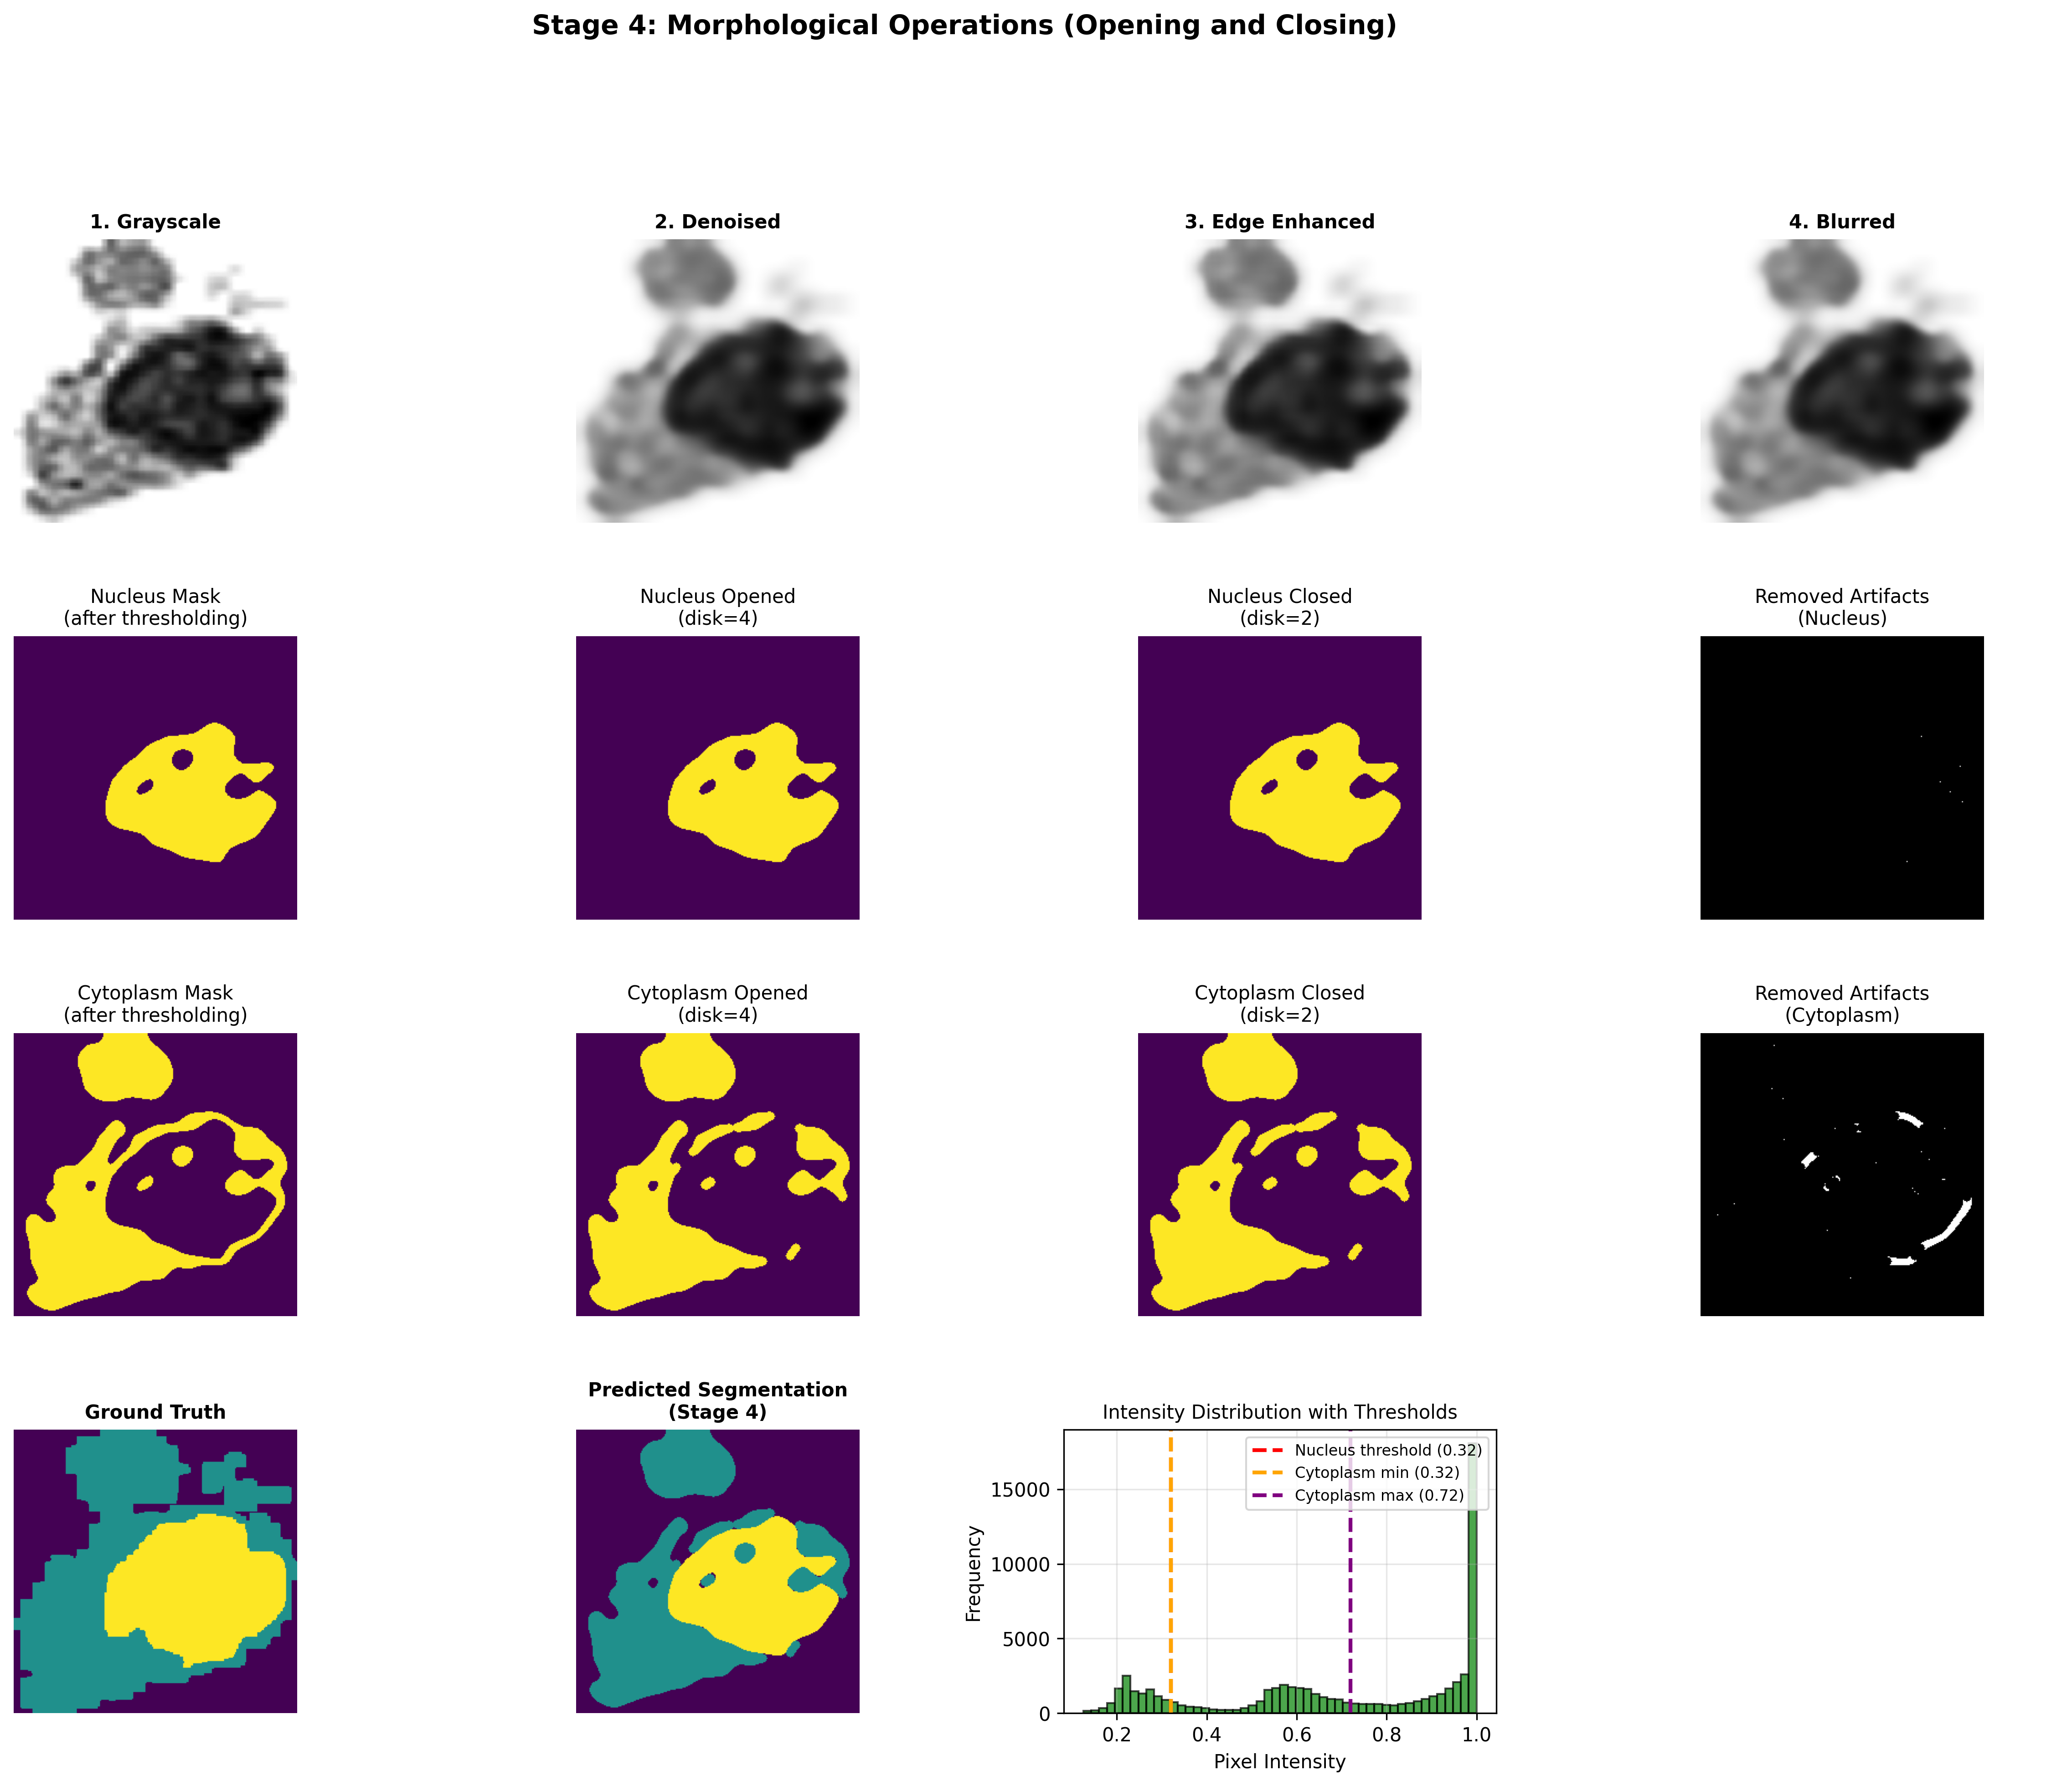


STAGE 4: MORPHOLOGICAL OPERATIONS
Class           Dice            IoU            
Background      0.7822          0.6423         
Cytoplasm       0.6856          0.5216         
Nucleus         0.8605          0.7552         
----------------------------------------------------------------------
Mean            0.7761          0.6397         

COMPLETE PIPELINE COMPARISON: All Stages
Metric                    Stage 1         Stage 2         Stage 3         Stage 4        
--------------------------------------------------------------------------------------------------------------
Dice_Cytoplasm            0.6564          0.6846          0.6848          0.6856         
Dice_Mean                 0.7610          0.7793          0.7797          0.7761         
Dice_Nucleus              0.8444          0.8596          0.8607          0.8605         
IoU_Cytoplasm             0.4885          0.5204          0.5207          0.5216         
IoU_Mean                  0.6206          0.6440   

In [32]:
from skimage.morphology import binary_opening, binary_closing, disk

# ============================================================================
# STAGE 4: ADD MORPHOLOGICAL OPERATIONS (OPENING AND CLOSING)
# ============================================================================

# Additional parameters for Stage 4
morph_disk_size = 4       # Size of morphological kernel
closing_disk_size = 2     # Size of closing kernel (typically smaller)

# STEPS 1-4: Same as Stage 3 (Grayscale → Denoise → Enhance → Blur)
img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

img_denoised = denoise_nl_means(
    img_gray,
    h=nl_means_strength,
    fast_mode=True,
    patch_size=10,
    patch_distance=10
)

img_enhanced = unsharp_mask(
    img_denoised,
    radius=unsharp_radius,
    amount=unsharp_amount
)

img_blurred = gaussian_filter(img_enhanced, sigma=blur_sigma)

# STEP 5: Intensity-Based Segmentation
nucleus_mask = (img_blurred < nucleus_max).astype(int)
cytoplasm_mask = np.logical_and(
    img_blurred >= cytoplasm_min,
    img_blurred <= cytoplasm_max
).astype(int)

# STEP 6: Morphological Operations
# Opening: Remove small artifacts
nucleus_opened = binary_opening(nucleus_mask, disk(morph_disk_size)).astype(int)
cytoplasm_opened = binary_opening(cytoplasm_mask, disk(morph_disk_size)).astype(int)

# Closing: Fill small holes
nucleus_closed = binary_closing(nucleus_opened, disk(closing_disk_size)).astype(int)
cytoplasm_closed = binary_closing(cytoplasm_opened, disk(closing_disk_size)).astype(int)

# STEP 7: Combine into 3-class segmentation
segmented = np.zeros_like(img_blurred, dtype=int)
segmented[nucleus_closed == 1] = 2
segmented[cytoplasm_closed == 1] = 1
# Background is implicitly 0

# STEP 8: Calculate Metrics
metrics_stage4 = calculate_all_metrics(segmented, labels_true, class_labels=[0, 1, 2])

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(4, 4, figsize=(20, 14))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Row 1: Processing Pipeline
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title("1. Grayscale", fontsize=10, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_denoised, cmap='gray')
axes[0, 1].set_title("2. Denoised", fontsize=10, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_enhanced, cmap='gray')
axes[0, 2].set_title("3. Edge Enhanced", fontsize=10, fontweight='bold')
axes[0, 2].axis('off')

axes[0, 3].imshow(img_blurred, cmap='gray')
axes[0, 3].set_title("4. Blurred", fontsize=10, fontweight='bold')
axes[0, 3].axis('off')

# Row 2: Nucleus Processing
axes[1, 0].imshow(nucleus_mask, cmap='viridis', vmin=0, vmax=1)
axes[1, 0].set_title("Nucleus Mask\n(after thresholding)", fontsize=10)
axes[1, 0].axis('off')

axes[1, 1].imshow(nucleus_opened, cmap='viridis', vmin=0, vmax=1)
axes[1, 1].set_title(f"Nucleus Opened\n(disk={morph_disk_size})", fontsize=10)
axes[1, 1].axis('off')

axes[1, 2].imshow(nucleus_closed, cmap='viridis', vmin=0, vmax=1)
axes[1, 2].set_title(f"Nucleus Closed\n(disk={closing_disk_size})", fontsize=10)
axes[1, 2].axis('off')

artifacts = nucleus_mask - nucleus_opened
axes[1, 3].imshow(artifacts, cmap='gray')
axes[1, 3].set_title("Removed Artifacts\n(Nucleus)", fontsize=10)
axes[1, 3].axis('off')

# Row 3: Cytoplasm Processing
axes[2, 0].imshow(cytoplasm_mask, cmap='viridis', vmin=0, vmax=1)
axes[2, 0].set_title("Cytoplasm Mask\n(after thresholding)", fontsize=10)
axes[2, 0].axis('off')

axes[2, 1].imshow(cytoplasm_opened, cmap='viridis', vmin=0, vmax=1)
axes[2, 1].set_title(f"Cytoplasm Opened\n(disk={morph_disk_size})", fontsize=10)
axes[2, 1].axis('off')

axes[2, 2].imshow(cytoplasm_closed, cmap='viridis', vmin=0, vmax=1)
axes[2, 2].set_title(f"Cytoplasm Closed\n(disk={closing_disk_size})", fontsize=10)
axes[2, 2].axis('off')

artifacts_cyto = cytoplasm_mask - cytoplasm_opened
axes[2, 3].imshow(artifacts_cyto, cmap='gray')
axes[2, 3].set_title("Removed Artifacts\n(Cytoplasm)", fontsize=10)
axes[2, 3].axis('off')

# Row 4: Final Segmentation and Ground Truth
axes[3, 0].imshow(labels_true, cmap='viridis', vmin=0, vmax=2)
axes[3, 0].set_title("Ground Truth", fontsize=10, fontweight='bold')
axes[3, 0].axis('off')

axes[3, 1].imshow(segmented, cmap='viridis', vmin=0, vmax=2)
axes[3, 1].set_title("Predicted Segmentation\n(Stage 4)", fontsize=10, fontweight='bold')
axes[3, 1].axis('off')

axes[3, 2].hist(img_blurred.flatten(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[3, 2].axvline(nucleus_max, color='red', linestyle='--', linewidth=2,
             label=f'Nucleus threshold ({nucleus_max})')
axes[3, 2].axvline(cytoplasm_min, color='orange', linestyle='--', linewidth=2,
             label=f'Cytoplasm min ({cytoplasm_min})')
axes[3, 2].axvline(cytoplasm_max, color='purple', linestyle='--', linewidth=2,
             label=f'Cytoplasm max ({cytoplasm_max})')
axes[3, 2].set_xlabel('Pixel Intensity', fontsize=10)
axes[3, 2].set_ylabel('Frequency', fontsize=10)
axes[3, 2].set_title("Intensity Distribution with Thresholds", fontsize=10)
axes[3, 2].legend(fontsize=8)
axes[3, 2].grid(alpha=0.3)

axes[3, 3].axis('off')

plt.suptitle('Stage 4: Morphological Operations (Opening and Closing)',
             fontsize=14, fontweight='bold', y=0.998)
plt.show()

# Print metrics and comparison
print("\n" + "="*70)
print("STAGE 4: MORPHOLOGICAL OPERATIONS")
print("="*70)
print_metrics(metrics_stage4)

print("\n" + "="*70)
print("COMPLETE PIPELINE COMPARISON: All Stages")
print("="*70)
print(f"{'Metric':<25} {'Stage 1':<15} {'Stage 2':<15} {'Stage 3':<15} {'Stage 4':<15}")
print("-"*110)
for key in sorted(metrics_stage1.keys()):
    if 'Mean' in key or 'Nucleus' in key or 'Cytoplasm' in key:
        s1 = metrics_stage1[key]
        s2 = metrics_stage2[key]
        s3 = metrics_stage3[key]
        s4 = metrics_stage4[key]
        print(f"{key:<25} {s1:<15.4f} {s2:<15.4f} {s3:<15.4f} {s4:<15.4f}")